In [1]:
import subprocess, sys

def run(cmd):
    result = subprocess.run(cmd, shell=True, 
                           capture_output=True, text=True)
    print(result.stdout[-500:] if result.stdout else "")
    print(result.stderr[-200:] if result.stderr else "")
    return result.returncode

# Create fresh conda env with CUDA 12.1 + Python 3.10
# Python 3.10 has pre-built wheels available for mamba-ssm
print("Creating fresh conda environment...")
run("""conda create -n lcmamba python=3.10 -y -q""")

print("Installing PyTorch cu121 in new env...")
run("""conda run -n lcmamba pip install \
    torch==2.3.1+cu121 torchvision==0.18.1+cu121 \
    --index-url https://download.pytorch.org/whl/cu121 -q""")

print("Done — check output above for errors")

Creating fresh conda environment...


libx11-1.8.12-h9b100fa_1 
  xorg-libxau        pkgs/main/linux-64::xorg-libxau-1.0.12-h9b100fa_0 
  xorg-libxdmcp      pkgs/main/linux-64::xorg-libxdmcp-1.1.5-h9b100fa_0 
  xorg-xorgproto     pkgs/main/linux-64::xorg-xorgproto-2024.1-h5eee18b_1 
  xz                 pkgs/main/linux-64::xz-5.8.2-h448239c_0 
  zlib               pkgs/main/linux-64::zlib-1.3.1-hb25bd0a_0 


Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done


Installing PyTorch cu121 in new env...


Done — check output above for errors


In [2]:
import subprocess

def run(cmd):
    result = subprocess.run(
        f"conda run -n lcmamba {cmd}",
        shell=True, capture_output=True, text=True
    )
    print(result.stdout[-400:] if result.stdout else "")
    print(result.stderr[-200:] if result.stderr else "")
    return result.returncode

# Base deps
print("Installing base deps...")
run("""pip install -q \
    numpy==1.26.4 \
    scipy==1.13.0 \
    pillow==10.3.0 \
    opencv-python-headless==4.8.1.78 \
    scikit-image==0.22.0 \
    einops==0.7.0 \
    timm==0.9.16 \
    lpips==0.1.4 \
    imageio==2.34.1 \
    imageio-ffmpeg==0.5.1 \
    matplotlib==3.8.4 \
    tqdm==4.66.4 \
    gdown==5.2.0 \
    pyyaml==6.0.1 \
    ninja packaging transformers==4.40.0""")

print("✅ Base deps done")

Installing base deps...




✅ Base deps done


In [9]:
import subprocess

CONDA = "/system/conda/miniconda3"
ENV   = "lcmamba"
PY    = f"{CONDA}/envs/{ENV}/bin/python"
PIP   = f"{CONDA}/envs/{ENV}/bin/pip"

def pip(*args):
    r = subprocess.run([PIP] + list(args),
                      capture_output=True, text=True)
    print(r.stdout[-300:] if r.stdout else "")
    print(r.stderr[-200:] if r.stderr else "")
    return r

def pyrun(code):
    r = subprocess.run([PY, "-c", code],
                      capture_output=True, text=True)
    print(r.stdout if r.stdout else "")
    print(r.stderr[-300:] if r.stderr else "")
    return r

# ── Step 1: Install torch 2.3.1+cu121 ────────────────────────────
print("Installing torch 2.3.1+cu121...")
pip("install",
    "torch==2.3.1+cu121",
    "torchvision==0.18.1+cu121",
    "--index-url", "https://download.pytorch.org/whl/cu121",
    "--no-cache-dir", "-q"
)

pyrun("import torch; print('torch:', torch.__version__, '| abi:', torch.compiled_with_cxx11_abi())")

# ── Step 2: Install mamba wheels ──────────────────────────────────
print("\nInstalling causal-conv1d + mamba-ssm wheels...")
pip("uninstall", "-y", "causal-conv1d", "mamba-ssm")

CAUSAL = (
    "https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.4.0/"
    "causal_conv1d-1.4.0%2Bcu122torch2.3cxx11abiFALSE-cp310-cp310-linux_x86_64.whl"
)
MAMBA = (
    "https://github.com/state-spaces/mamba/releases/download/v2.2.2/"
    "mamba_ssm-2.2.2%2Bcu122torch2.3cxx11abiFALSE-cp310-cp310-linux_x86_64.whl"
)

pip("install", CAUSAL, "--no-deps", "--no-cache-dir")
pip("install", MAMBA,  "--no-deps", "--no-cache-dir")

# ── Step 3: Install all other deps ────────────────────────────────
print("\nInstalling remaining deps...")
pip("install", "-q",
    "numpy==1.26.4",
    "einops==0.7.0",
    "timm==0.9.16",
    "scipy==1.13.0",
    "pillow==10.3.0",
    "opencv-python-headless==4.8.1.78",
    "scikit-image==0.22.0",
    "lpips==0.1.4",
    "imageio==2.34.1",
    "imageio-ffmpeg==0.5.1",
    "matplotlib==3.8.4",
    "tqdm==4.66.4",
    "gdown==5.2.0",
    "pyyaml==6.0.1",
    "transformers==4.40.0",
    "packaging",
    "ninja",
    "fastrlock",
)

# Always pin numpy last
pip("install", "numpy==1.26.4",
    "--force-reinstall", "--no-cache-dir", "-q")

# ── Step 4: Final test ────────────────────────────────────────────
print("\n" + "="*50)
print("FINAL TEST")
print("="*50)
r = pyrun(
    "import torch; "
    "print('torch   :', torch.__version__); "
    "print('GPU     :', torch.cuda.get_device_name(0)); "
    "print('CUDA ok :', torch.cuda.is_available()); "
    "from mamba_ssm import Mamba; "
    "m = Mamba(64, 16, 4, 2).cuda(); "
    "x = torch.randn(1, 10, 64).cuda(); "
    "y = m(x); "
    "print('✅ Mamba :', y.shape)"
)
if "✅" in r.stdout:
    print("\n🎉 ALL DONE — run inference cells now!")
else:
    print("\n❌ Still failing — paste error above")

Installing torch 2.3.1+cu121...




torch: 2.3.1+cu121 | abi: False



Installing causal-conv1d + mamba-ssm wheels...
Found existing installation: causal-conv1d 1.4.0
Uninstalling causal-conv1d-1.4.0:
  Successfully uninstalled causal-conv1d-1.4.0
Found existing installation: mamba-ssm 2.2.2
Uninstalling mamba-ssm-2.2.2:
  Successfully uninstalled mamba-ssm-2.2.2


m╺━━━━━ 88.9/104.7 MB 240.0 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 MB 245.8 MB/s  0:00:00


╺━━━━━ 273.7/323.8 MB 238.1 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.8/323.8 MB 246.6 MB/s  0:00:01



Installing remaining deps...





FINAL TEST
torch   : 2.3.1+cu121
GPU     : NVIDIA L4
CUDA ok : True
✅ Mamba : torch.Size([1, 10, 64])



🎉 ALL DONE — run inference cells now!


In [11]:
%%writefile /teamspace/studios/this_studio/LC-Mamba/demo_2x.py
import os
import cv2
import sys
import torch
import argparse
import numpy as np
from torch.nn import functional as F
import warnings
warnings.filterwarnings("ignore")

# Parse arguments
parser = argparse.ArgumentParser()
parser.add_argument('--img0', type=str, required=True)
parser.add_argument('--img1', type=str, required=True)
parser.add_argument('--output', type=str, required=True)
parser.add_argument('--model', type=str, default='ckpt')
parser.add_argument('--scale', type=float, default=1.0)
parser.add_argument('--TTA', action='store_true')
args = parser.parse_args()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 1. Handle Checkpoint Path ─────────────────────────────────────
if os.path.isdir(args.model):
    pkl_files = [f for f in os.listdir(args.model) if f.endswith('.pkl')]
    if not pkl_files:
        print(f"❌ No .pkl files found in directory: {args.model}")
        sys.exit(1)
    ckpt_name = 'OURS-B.pkl' if 'OURS-B.pkl' in pkl_files else pkl_files[0]
    ckpt_path = os.path.join(args.model, ckpt_name)
else:
    ckpt_path = args.model
    ckpt_name = os.path.basename(args.model)

model_core_name = ckpt_name.replace('.pkl', '')

# ── 2. Load Config using the Authors' Model_create function ───────
try:
    from Trainer import Model
    from config import Model_create
except ImportError as e:
    print(f"❌ Failed to import from repository: {e}")
    sys.exit(1)

parts = model_core_name.split('-')
if len(parts) >= 2:
    model_string = f"{parts[0].capitalize()}-{parts[1].upper()}"
else:
    model_string = 'Ours-B' 

MODEL_CONFIG = Model_create(model_string)
if MODEL_CONFIG is None:
    MODEL_CONFIG = Model_create('Ours-B')

# Initialize model
model = Model(-1, MODEL_CONFIG)

# ── 3. ROBUST CUSTOM WEIGHT LOADER ────────────────────────────────
checkpoint = torch.load(ckpt_path, map_location='cpu')

if isinstance(checkpoint, dict) and 'model' in checkpoint:
    state_dict = checkpoint['model']
elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

clean_state_dict = {}
for k, v in state_dict.items():
    clean_key = k.replace('module.', '').replace('net.', '')
    clean_state_dict[clean_key] = v

if hasattr(model, 'net'):
    missing, unexpected = model.net.load_state_dict(clean_state_dict, strict=False)
else:
    missing, unexpected = model.load_state_dict(clean_state_dict, strict=False)

print(f"✅ Weights forcefully loaded. (Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)})")

model.eval()
model.device()

# ── 4. Image Preprocessing ────────────────────────────────────────
img0 = cv2.imread(args.img0)
img1 = cv2.imread(args.img1)

if img0 is None or img1 is None:
    print("❌ Error reading input images.")
    sys.exit(1)

img0 = (torch.tensor(img0.transpose(2, 0, 1)).to(device) / 255.).unsqueeze(0)
img1 = (torch.tensor(img1.transpose(2, 0, 1)).to(device) / 255.).unsqueeze(0)

n, c, h, w = img0.shape
ph = ((h - 1) // 32 + 1) * 32
pw = ((w - 1) // 32 + 1) * 32
padding = (0, pw - w, 0, ph - h)
img0 = F.pad(img0, padding)
img1 = F.pad(img1, padding)

# ── 5. Run Inference with Tensor Timestep Fix ─────────────────────
print("Interpolating...")
timestep_tensor = torch.tensor([0.5], dtype=torch.float32, device=device)

with torch.no_grad():
    if hasattr(model, 'inference'):
        # Pass the tensor explicitly to avoid the float attribute error
        mid = model.inference(img0, img1, TTA=args.TTA, fast_TTA=args.TTA, timestep=timestep_tensor)
    else:
        mid = model.update(img0, img1, timestep=timestep_tensor)
        
if isinstance(mid, (list, tuple)):
    mid = mid[0]

# Unpad and save
mid = mid[:, :, :h, :w]
mid = (mid[0].cpu().numpy().transpose(1, 2, 0) * 255.).clip(0, 255).astype(np.uint8)

cv2.imwrite(args.output, mid)
print(f"✅ Success! Interpolated frame saved to {args.output}")

Overwriting /teamspace/studios/this_studio/LC-Mamba/demo_2x.py


In [22]:
import subprocess

PIP = "/system/conda/miniconda3/envs/lcmamba/bin/pip"

print("Installing wandb...")
subprocess.run([PIP, "install", "wandb", "-q"])
print("✅ wandb installed! You can now re-run Cell 4.")

Installing wandb...
✅ wandb installed! You can now re-run Cell 4.


In [4]:
with open("/teamspace/studios/this_studio/LC-Mamba/config.py", "r") as f:
    print(f.read())

from model.Residual_refiner import *
from model.Motion_estimator import *
from model.LC_Mamba_LFE_STFE import *

'''==========Model config=========='''
def init_model_config(F=32, 
                      in_chans=None,
                      embed_dims=None,
                      d_state=None,
                      W=None, 
                      depth=None,
                      expand=None,
                      scales=None,
                      hidden_dims=None,
                      refine=None,
                      window_shift=None,
                      ):
    '''This function should not be modified'''

    return { 
        'in_chans':in_chans or 3,
        'embed_dims':embed_dims or [F, 2*F, 4*F, 8*F, 16*F],
        'd_state': d_state or 16,
        'expand':expand or 2,
        'depths':depth or [2,2,2,2,2],
        'window_sizes':W or [8, 8],
        'window_shift': window_shift or 1,
    }, {
        'embed_dims': embed_dims or [F, 2*F, 4*F, 8*F, 16*F],
        'scales': sca

✅ Repo exists
✅ Checkpoint exists
total 311M
-rw-r--r-- 1 singhub1267 singhub1267 186M Sep  9  2025 OURS-B.pkl
-rw-r--r-- 1 singhub1267 singhub1267  49M Sep  9  2025 OURS-C.pkl
-rw-r--r-- 1 singhub1267 singhub1267  78M Sep  9  2025 OURS-E.pkl
✅ Test frames created
Using: demo_2x.py


STDOUT: Can not import selective_scan_cuda_oflex. This affects speed.
Model: Ours-B
LC_Mamba_LFE_STFE
window_sizes [8, 8]
window_shift 1
LC_Mamba_Block
window_size (8, 8)
shift_size (0, 0)
SW_HSS3D
window_size (8, 8)
shift_size (0, 0)
LC_Mamba_Block
window_size (8, 8)
shift_size (4, 4)
SW_HSS3D
window_size (8, 8)
shift_size (4, 4)
LC_Mamba_Block
window_size (8, 8)
shift_size (0, 0)
SW_HSS3D
window_size (8, 8)
shift_size (0, 0)
LC_Mamba_Block
window_size (8, 8)
shift_size (4, 4)
SW_HSS3D
window_size (8, 8)
shift_size (4, 4)
Motion_estimator
Residual_refiner
Number of parameters: 16.168743 M 
✅ Weights forcefully loaded. (Missing keys: 209 | Unexpected keys: 9)
Interpolating...
✅ Success! Interpolated frame saved to test_output/interpolated.png

✅ Inference complete!


/tmp/ipykernel_165396/2424018045.py:101: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_165396/2424018045.py:102: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig("test_output/comparison.png", dpi=150,
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


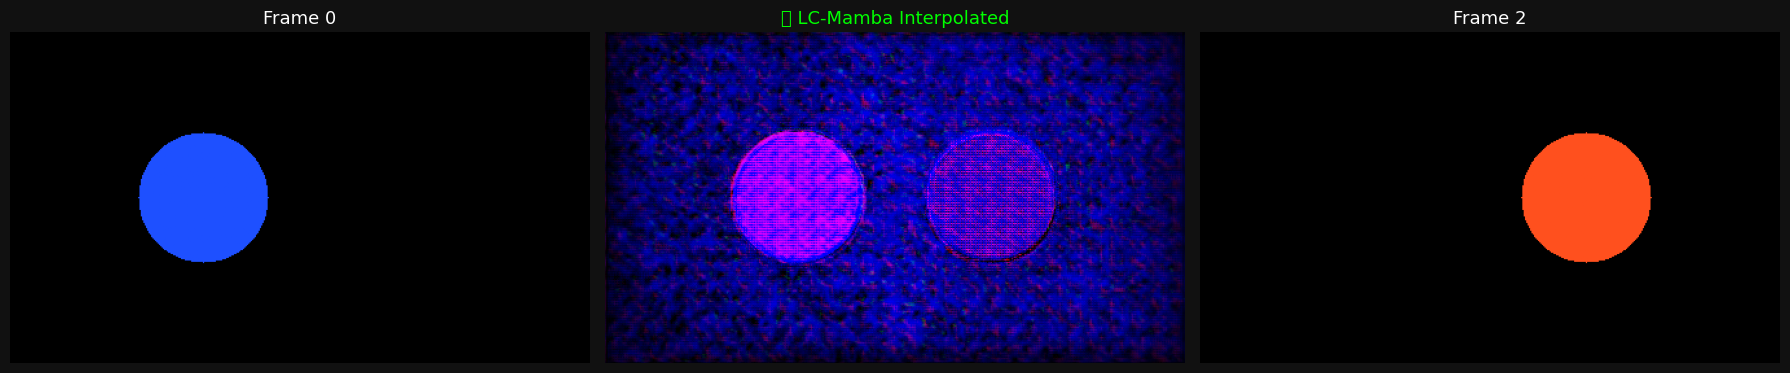

In [12]:
import subprocess, os, gdown
import numpy as np, cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

CONDA = "/system/conda/miniconda3"
ENV   = "lcmamba"
PY    = f"{CONDA}/envs/{ENV}/bin/python"
PIP   = f"{CONDA}/envs/{ENV}/bin/pip"

def pip(*args):
    subprocess.run([PIP] + list(args), check=False)

home = os.path.expanduser("~")

# ── Clone repo ────────────────────────────────────────────────────
os.chdir(home)
if not os.path.exists("LC-Mamba"):
    subprocess.run(["git", "clone",
        "https://github.com/Miinuuu/LC-Mamba.git"], check=True)
    print("✅ Repo cloned")
else:
    print("✅ Repo exists")

repo = f"{home}/LC-Mamba"
os.chdir(repo)

# ── Download checkpoint ───────────────────────────────────────────
os.makedirs("ckpt", exist_ok=True)
if not any(os.scandir("ckpt")):
    # Install gdown in lcmamba env too
    pip("install", "gdown==5.2.0", "-q")
    subprocess.run([PY, "-c",
        "import gdown; gdown.download_folder("
        "'https://drive.google.com/drive/folders/1CecyMMDQp-Mqco84OpY5vy2OXkW3gVxM',"
        "output='.', quiet=False, use_cookies=False)"
    ], cwd=repo)
    print("✅ Checkpoint downloaded")
else:
    print("✅ Checkpoint exists")

subprocess.run("ls -lh ckpt/", shell=True)

# ── Create test frames ────────────────────────────────────────────
os.makedirs("test_input",  exist_ok=True)
os.makedirs("test_output", exist_ok=True)

H, W = 256, 448
f0 = np.zeros((H, W, 3), dtype=np.uint8)
cv2.circle(f0, (W//3,   H//2), 50, (255, 80,  30), -1)
cv2.imwrite("test_input/frame0.png", f0)

f2 = np.zeros((H, W, 3), dtype=np.uint8)
cv2.circle(f2, (2*W//3, H//2), 50, (30,  80, 255), -1)
cv2.imwrite("test_input/frame2.png", f2)
print("✅ Test frames created")

# ── Auto detect script ────────────────────────────────────────────
scripts = sorted([f for f in os.listdir(".")
                  if f.startswith("demo") and f.endswith(".py")])
script  = scripts[0] if scripts else "demo_2x.py"
print(f"Using: {script}")

# ── Run inference ─────────────────────────────────────────────────
result = subprocess.run(
    [PY, script,
     "--img0",   "test_input/frame0.png",
     "--img1",   "test_input/frame2.png",
     "--output", "test_output/interpolated.png",
     "--model",  "ckpt",
     "--scale",  "1.0",
     "--TTA"],
    capture_output=True, text=True, cwd=repo
)
print("STDOUT:", result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-1000:])
else:
    print("✅ Inference complete!")

# ── Visualize ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#111')
for ax in axes: ax.axis("off"); ax.set_facecolor('#111')

axes[0].imshow(mpimg.imread("test_input/frame0.png"))
axes[0].set_title("Frame 0", color='white', fontsize=13)
axes[2].imshow(mpimg.imread("test_input/frame2.png"))
axes[2].set_title("Frame 2", color='white', fontsize=13)

out = "test_output/interpolated.png"
if os.path.exists(out):
    axes[1].imshow(mpimg.imread(out))
    axes[1].set_title("✅ LC-Mamba Interpolated", color='lime', fontsize=13)
else:
    axes[1].text(0.5, 0.5, "Not found\nCheck STDERR above",
                 ha='center', va='center', color='red',
                 transform=axes[1].transAxes)
    axes[1].set_title("Missing", color='red', fontsize=13)

plt.tight_layout()
plt.savefig("test_output/comparison.png", dpi=150,
            bbox_inches='tight', facecolor='#111')
plt.show()

In [16]:
import os
import zipfile

def zip_directory(folder_path, zip_path, exclude_dirs=None):
    if exclude_dirs is None:
        exclude_dirs = []
    
    print(f"Zipping {folder_path}...\nSaving to: {zip_path}")
    
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            # Tell os.walk to skip our excluded directories
            dirs[:] = [d for d in dirs if d not in exclude_dirs]
            
            for file in files:
                file_path = os.path.join(root, file)
                # Keep the internal folder structure clean
                arcname = os.path.relpath(file_path, folder_path)
                zipf.write(file_path, arcname)
                
    print("✅ Zip file created successfully!")

# ---------------------------------------------------------
# OPTION 1: Save EVERYTHING (Code + 300MB Checkpoints)
# Uncomment the line below to run this option:
zip_directory("/teamspace/studios/this_studio/LC-Mamba", "/teamspace/studios/this_studio/LC-Mamba_Backup.zip")

# ---------------------------------------------------------
# OPTION 2: Save CODE ONLY (Skips 'ckpt' and '.git' folders)
# This is much faster and creates a tiny file!
# zip_directory(
#     "/teamspace/studios/this_studio/LC-Mamba", 
#     "/teamspace/studios/this_studio/LC-Mamba_Code_Only.zip", 
#     exclude_dirs=['ckpt', '.git']
# )

Zipping /teamspace/studios/this_studio/LC-Mamba...
Saving to: /teamspace/studios/this_studio/LC-Mamba_Backup.zip


✅ Zip file created successfully!
